# Laboratorio 1 - Milton Beltran
---

In [1]:
# =========================================================
# Importación de librerías
# =========================================================

# --- Librerías estándar de Python ---
import re                        # expresiones regulares (limpieza / puntuación)
import string                    # constantes útiles (p. ej. string.punctuation)
from collections import Counter  # conteo de frecuencias de palabras

# --- Manejo de datos y gráficos ---
import pandas as pd              # cargar y manipular el corpus (DataFrame)
import numpy as np               # cálculos numéricos (ej. Ley de Zipf en log-log)
import matplotlib.pyplot as plt  # gráficos (histograma, Zipf, etc.)

# --- NLP con NLTK ---
import nltk
from nltk.tokenize import word_tokenize  # tokenización
from nltk.corpus import stopwords        # stopwords 
from nltk.stem import SnowballStemmer     # "lematización" (stemming) en español

# --- Nube de palabras ---
from wordcloud import WordCloud       

In [2]:
# --- Carga del corpus ---
# Archivo descargado de Kaggle (Spanish News Classification)
df = pd.read_csv("df_total.csv")

# Vistazo inicial a las primeras filas
df.head()

,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


## 2. Exploración del Corpus

En esta sección solo **observamos** el corpus, sin modificarlo, para responder:


In [3]:
# --- Exploración inicial (solo observar, sin modificar el corpus) ---

# 1) ¿Cuántos documentos tiene el corpus?
print("Número de documentos (filas):", df.shape[0])

# 2) ¿Qué columnas contiene y de qué tipo son?
print("\nColumnas:", list(df.columns))
df.info()

# 3) ¿Cuántas categorías hay y cómo se distribuyen?
print("\nNúmero de categorías:", df["Type"].nunique())
print("\nDistribución por categoría:")
print(df["Type"].value_counts())

# 4) ¿Hay filas vacías (nulas) o duplicadas?
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas (fila completa):", df.duplicated().sum())
# Duplicados considerando solo el texto de la noticia:
print("Noticias con texto duplicado:", df["news"].duplicated().sum())

Número de documentos (filas): 1217

Columnas: ['url', 'news', 'Type']
<class 'pandas.DataFrame'>
RangeIndex: 1217 entries, 0 to 1216
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   url     1217 non-null   str  
 1   news    1217 non-null   str  
 2   Type    1217 non-null   str  
dtypes: str(3)
memory usage: 28.7 KB

Número de categorías: 7

Distribución por categoría:
Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64

Valores nulos por columna:
url     0
news    0
Type    0
dtype: int64

Filas duplicadas (fila completa): 75
Noticias con texto duplicado: 79


**- ¿Cuántos documentos tiene el corpus?**

En el corpus hay un total de 1217 documentos, la cantidad de noticias individuales que hay dentro del dataset.

**- ¿Qué columnas contiene y qué información guarda cada una?**

El corpus cuenta con 3 columnas., 'url', 'news' y 'Type'>
    - url: enlace a la fuente de la noticia (ej. larepublica.co). Es metadato, no lo usaremos para el análisis de texto.
    - news: el texto completo de la noticia. Es la columna sobre la que aplicaremos el pipeline.
    - Type: la categoría/etiqueta de la noticia (sería el target si esto fuera clasificación).

**- ¿Cuántas categorías hay y cómo se distribuyen?**
Hay 7 categorías, todas de temática empresarial/económica. Su distribución es:
 Categoría | Documentos |
|-----------|-----------:|
| Macroeconomia  | 340 |
| Alianzas       | 247 |
| Innovacion     | 195 |
| Regulaciones   | 142 |
| Sostenibilidad | 137 |
| Otra           | 130 |
| Reputacion     | 26 |

La distribución está bastante desbalanceada: Macroeconomía (340) tiene la mayor parte y tiene ~13 veces más documentos que Reputación (26). 

**- ¿Hay filas vacías o duplicadas?**
- _Vacías (nulos):_ no hay. Las tres columnas tienen 1217 valores no nulos.
- _Duplicadas:_ sí. Hay 75 filas completamente duplicadas (idénticas en las tres columnas) y 79 documentos con el texto de `news` repetido. La diferencia de 4 casos corresponde a noticias con el mismo texto pero distinta `url` o `Type`, lo que sugiere un pequeño problema de calidad de datos (por ejemplo, una misma noticia etiquetada en más de una categoría).


## 3. Preparación del corpus (pipeline de normalización)

Aplicamos el pipeline, después de cada paso, contamos **tokens**  y **tipos**.

**Decisiones tomadas:**
- Se eliminan las 75 filas exactamente duplicadas antes de normalizar.
- Los tokens se guardan **por documento** (columna de listas) para poder analizar por documento y por categoría en la Sección 5.
- En "eliminar puntuación" usamos `token.isalpha()`: quita signos (incluidos `¿ ¡`) y conserva tildes/`ñ`. Costo asumido: también descarta números y tokens mixtos (`5G`).

Pipeline: **tokenización → minúsculas → quitar puntuación → quitar stopwords → stemming**.

In [4]:
# --- Paso 0: eliminar filas duplicadas exactas ---
# Trabajamos sobre una copia para no modificar el df original de la exploración.
df_prep = df.drop_duplicates().reset_index(drop=True)

print("Documentos originales:", len(df))
print("Documentos tras quitar duplicados:", len(df_prep))

Documentos originales: 1217
Documentos tras quitar duplicados: 1142


In [5]:
# --- Función auxiliar: contar tokens y tipos sobre todo el corpus ---
def contar(col_de_listas):
    """Recibe una Serie donde cada fila es una lista de tokens.
    Devuelve (total_tokens, total_tipos) agregando todo el corpus.

    - tokens: total de ocurrencias (con repeticiones).
    - tipos:  palabras distintas (el vocabulario).
    """
    todos = [tok for lista in col_de_listas for tok in lista]  # aplanar
    total_tokens = len(todos)
    total_tipos = len(set(todos))
    return total_tokens, total_tipos

In [6]:
# --- Paso 1: Tokenización ---
# Dividimos cada noticia en tokens. Usamos language="spanish" para que el
df_prep["tokens"] = df_prep["news"].apply(
    lambda t: word_tokenize(t, language="spanish")
)

tok, tip = contar(df_prep["tokens"])
print(f"[i. Tokenización]  tokens={tok:,}  tipos={tip:,}")

print("\nEjemplo (primeros 20 tokens del doc 0):")
print(df_prep["tokens"].iloc[0][:20])

[i. Tokenización]  tokens=632,745  tipos=38,947

Ejemplo (primeros 20 tokens del doc 0):
['Durante', 'el', 'foro', 'La', 'banca', 'articulador', 'empresarial', 'para', 'el', 'desarrollo', 'sostenible', 'el', 'director', 'de', 'sostenibilidad', 'y', 'clientes', 'globales', 'de', 'BBVA']


In [7]:
# --- Paso 2: Minúsculas ---
# Pasamos cada token a minúsculas para unificar variantes ("El", "el", "EL" -> "el").
df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok.lower() for tok in lista]
)

tok, tip = contar(df_prep["tokens"])
print(f"[ii. Minúsculas]  tokens={tok:,}  tipos={tip:,}")

print("\nEjemplo (primeros 20 tokens del doc 0):")
print(df_prep["tokens"].iloc[0][:20])

[ii. Minúsculas]  tokens=632,745  tipos=36,099

Ejemplo (primeros 20 tokens del doc 0):
['durante', 'el', 'foro', 'la', 'banca', 'articulador', 'empresarial', 'para', 'el', 'desarrollo', 'sostenible', 'el', 'director', 'de', 'sostenibilidad', 'y', 'clientes', 'globales', 'de', 'bbva']


In [8]:
# --- Paso 3:   Eliminar puntuación ---
# Conservamos solo tokens alfabéticos con isalpha(). Esto elimina signos de  puntuación (incluidos ¿ ¡ « » y comillas) y también números/tokens mixtos.
df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok for tok in lista if tok.isalpha()]
)

tok, tip = contar(df_prep["tokens"])
print(f"[iii. Quitar puntuación]  tokens={tok:,}  tipos={tip:,}")

print("\nEjemplo (primeros 20 tokens del doc 0):")
print(df_prep["tokens"].iloc[0][:20])

[iii. Quitar puntuación]  tokens=579,676  tipos=27,315

Ejemplo (primeros 20 tokens del doc 0):
['durante', 'el', 'foro', 'la', 'banca', 'articulador', 'empresarial', 'para', 'el', 'desarrollo', 'sostenible', 'el', 'director', 'de', 'sostenibilidad', 'y', 'clientes', 'globales', 'de', 'bbva']


In [9]:
# --- Paso 4:   Eliminar stopwords ---
# Stopwords = palabras muy frecuentes y poco informativas (de, la, que, el, ...).
stop_es = set(stopwords.words("spanish"))
print("Cantidad de stopwords en español (NLTK):", len(stop_es))

df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok for tok in lista if tok not in stop_es]
)

tok, tip = contar(df_prep["tokens"])
print(f"[iv. Quitar stopwords]  tokens={tok:,}  tipos={tip:,}")

print("\nEjemplo (primeros 20 tokens del doc 0):")
print(df_prep["tokens"].iloc[0][:20])

Cantidad de stopwords en español (NLTK): 313
[iv. Quitar stopwords]  tokens=299,799  tipos=27,104

Ejemplo (primeros 20 tokens del doc 0):
['foro', 'banca', 'articulador', 'empresarial', 'desarrollo', 'sostenible', 'director', 'sostenibilidad', 'clientes', 'globales', 'bbva', 'colombia', 'andrés', 'garcía', 'aseguró', 'importante', 'entender', 'sostenibilidad', 'podemos', 'asociar']


In [10]:
# --- Paso v: Stemming ("lematización" con NLTK) ---
# NLTK no tiene lematizador para español (WordNet es solo inglés), así que usamos SnowballStemmer('spanish'), que recorta cada palabra a una raíz aproximada.
# Técnicamente esto es STEMMING, no lematización real (corta sufijos, no lleva  a la forma de diccionario). Se documenta como decisión en el reporte.
#
# Guardamos DOS versiones del corpus preparado para el EDA (Sección 5):
#   - tokens_norm: normalizado SIN stemming (palabras legibles) -> nube y top-20
#   - tokens_stem: con stemming (raíces)                        -> conteos y Zipf
df_prep["tokens_norm"] = df_prep["tokens"]  # estado actual = post-stopwords (legible)

stemmer = SnowballStemmer("spanish")
df_prep["tokens_stem"] = df_prep["tokens_norm"].apply(
    lambda lista: [stemmer.stem(tok) for tok in lista]
)

tok, tip = contar(df_prep["tokens_stem"])
print(f"[v. Stemming]  tokens={tok:,}  tipos={tip:,}")

print("\nEjemplo doc 0 SIN stemming (legible):")
print(df_prep["tokens_norm"].iloc[0][:15])
print("\nEjemplo doc 0 CON stemming (raíces):")
print(df_prep["tokens_stem"].iloc[0][:15])

[v. Stemming]  tokens=299,799  tipos=13,103

Ejemplo doc 0 SIN stemming (legible):
['foro', 'banca', 'articulador', 'empresarial', 'desarrollo', 'sostenible', 'director', 'sostenibilidad', 'clientes', 'globales', 'bbva', 'colombia', 'andrés', 'garcía', 'aseguró']

Ejemplo doc 0 CON stemming (raíces):
['for', 'banc', 'articul', 'empresarial', 'desarroll', 'sosten', 'director', 'sostenibil', 'client', 'global', 'bbva', 'colombi', 'andres', 'garc', 'asegur']


## 4. ¿Qué es un EDA?

### 4.1. ¿Qué es un Análisis Exploratorio de Datos (EDA)?

El **Análisis Exploratorio de Datos** (EDA, del inglés *Exploratory Data Analysis*) es un enfoque metodológico para el análisis de conjuntos de datos orientado a **resumir sus características principales, comprender su estructura e identificar patrones, anomalías y relaciones**, apoyándose de manera intensiva en la **visualización** y en la **estadística descriptiva**. El término fue acuñado y formalizado por el estadístico **John W. Tukey** en su obra *Exploratory Data Analysis* (1977), como complemento al análisis confirmatorio tradicional.

Conceptualmente, el EDA se distingue del **Análisis Confirmatorio de Datos** (CDA):

| Dimensión | Análisis Exploratorio (EDA) | Análisis Confirmatorio (CDA) |
|-----------|-----------------------------|------------------------------|
| Propósito | *Generar* hipótesis y descubrir estructura | *Contrastar* hipótesis definidas a priori |
| Postura | Inductiva, abierta, iterativa | Deductiva, formal |
| Herramientas | Gráficos, resúmenes, tendencia y dispersión | Pruebas de hipótesis, intervalos de confianza |
| Momento | Fase inicial del proyecto | Fase posterior de validación |

Sus rasgos característicos son: (1) **naturaleza iterativa y flexible**; (2) **énfasis en lo visual** (histogramas, cajas y, para texto, tablas de frecuencia, curvas de Zipf y nubes de palabras); (3) **foco en la calidad de los datos** (nulos, duplicados, *outliers*, desbalances); y (4) **descripción antes que inferencia**. En NLP, el EDA se aplica sobre un *corpus*: se cuantifican documentos, *tokens* y *tipos*, tamaño del vocabulario, distribución de frecuencias y longitud de los documentos.

### 4.2. ¿Qué busca lograr un EDA dentro de un proyecto de ciencia de datos?

Dentro del ciclo de vida de un proyecto de ciencia de datos (p. ej., la fase de *Data Understanding* de **CRISP-DM**), el EDA busca: (1) **comprender la estructura y el contenido** de los datos; (2) **evaluar y garantizar su calidad**; (3) **descubrir patrones, tendencias y relaciones** (como la Ley de Zipf); (4) **detectar problemas que afectan el modelado** (desbalance de clases, ruido, alta dimensionalidad); (5) **fundamentar decisiones de preprocesamiento e ingeniería de características**; y (6) **formular y refinar hipótesis**. En síntesis, es una **etapa fundacional y de bajo riesgo** que reduce la incertidumbre y previene errores costosos en fases avanzadas.

> **Referencia:** Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.

## 5. EDA sobre el corpus

Con el corpus ya preparado (`df_prep`, con las columnas `tokens_norm` legible y
`tokens_stem` con stemming), calculamos los indicadores del EDA. Las figuras se guardan
en `reporte/img/` para incrustarlas en el reporte escrito.

Recordatorio de las dos versiones:
- **`tokens_norm`** (sin stemming, legible) → top-20, comparación por categoría y nube.
- **`tokens_stem`** (con stemming) → conteos globales y Ley de Zipf.

In [11]:
# 5.1 Tokens y tipos: antes vs. después de normalizar + % de reducción del vocabulario

# Función auxiliar para aplanar una columna de listas de tokens
def flatten(col):
    return [tok for lista in col for tok in lista]

# ANTES: solo tokenización cruda del texto original
crudo = df_prep["news"].apply(lambda t: word_tokenize(t, language="spanish"))
tok_antes, tip_antes = contar(crudo)

# DESPUÉS: corpus final normalizado (con stemming)
tok_desp, tip_desp = contar(df_prep["tokens_stem"])

reduccion_vocab = (1 - tip_desp / tip_antes) * 100
print(f"ANTES  (tokenización): tokens={tok_antes:,}  tipos={tip_antes:,}")
print(f"DESPUÉS (normalizado): tokens={tok_desp:,}  tipos={tip_desp:,}")
print(f"Reducción del vocabulario (tipos): {reduccion_vocab:.1f}%")

ANTES  (tokenización): tokens=632,745  tipos=38,947
DESPUÉS (normalizado): tokens=299,799  tipos=13,103
Reducción del vocabulario (tipos): 66.4%


In [12]:
# 5.2 Riqueza léxica: razón tipo/token (TTR), global y por categoría

def ttr(tokens):
    """Razón tipo/token: tipos / tokens (diversidad léxica)."""
    tokens = list(tokens)
    if not tokens:
        return 0, 0, 0.0
    return len(set(tokens)), len(tokens), len(set(tokens)) / len(tokens)

# Global (corpus normalizado legible)
ti, tk, r = ttr(flatten(df_prep["tokens_norm"]))
print(f"TTR global (legible): tipos={ti:,}  tokens={tk:,}  TTR={r:.4f}")

# Por categoría
print("\nTTR por categoría (corpus legible):")
for c in df_prep["Type"].value_counts().index:
    sub = flatten(df_prep.loc[df_prep["Type"] == c, "tokens_norm"])
    ci, ck, cr = ttr(sub)
    docs = (df_prep["Type"] == c).sum()
    print(f"  {c:15s} docs={docs:4d}  tokens={ck:7,}  tipos={ci:6,}  TTR={cr:.4f}")

TTR global (legible): tipos=27,104  tokens=299,799  TTR=0.0904

TTR por categoría (corpus legible):
  Macroeconomia   docs= 320  tokens= 85,042  tipos=11,320  TTR=0.1331
  Alianzas        docs= 247  tokens= 46,122  tipos=10,523  TTR=0.2282
  Innovacion      docs= 152  tokens= 49,185  tipos= 8,931  TTR=0.1816
  Regulaciones    docs= 142  tokens= 35,109  tipos= 8,815  TTR=0.2511
  Otra            docs= 130  tokens= 25,803  tipos= 5,576  TTR=0.2161
  Sostenibilidad  docs= 125  tokens= 51,341  tipos=10,333  TTR=0.2013
  Reputacion      docs=  26  tokens=  7,197  tipos= 2,976  TTR=0.4135


Top-20 palabras más frecuentes:
  bbva            2,160
  inflación       1,342
  año             1,304
  banco           1,079
  millones        1,077
  empresas        991
  precios         927
  clientes        857
  país            856
  colombia        834
  mayor           823
  parte           776
  crecimiento     772
  años            724
  mercado         713
  energía         709
  ser             695
  así             665
  además          658
  sector          656


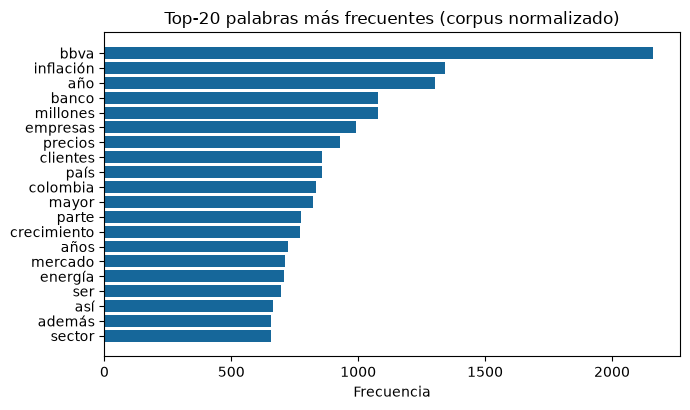

In [13]:
# 5.3 Tabla de frecuencias: 20 palabras más frecuentes (corpus normalizado legible)
frec = Counter(flatten(df_prep["tokens_norm"]))
top20 = frec.most_common(20)
print("Top-20 palabras más frecuentes:")
for palabra, f in top20:
    print(f"  {palabra:15s} {f:,}")

# Figura (barras horizontales) para el reporte
palabras = [w for w, _ in top20][::-1]
valores = [f for _, f in top20][::-1]
plt.figure(figsize=(7, 4.2))
plt.barh(palabras, valores, color="#16679a")
plt.xlabel("Frecuencia")
plt.title("Top-20 palabras más frecuentes (corpus normalizado)")
plt.tight_layout()
plt.savefig("reporte/img/top20.png", dpi=120)
plt.show()

count    1142.000000
mean      262.521016
std       178.570492
min         0.000000
25%       139.000000
50%       226.000000
75%       325.000000
max      1479.000000
Name: tokens_norm, dtype: float64


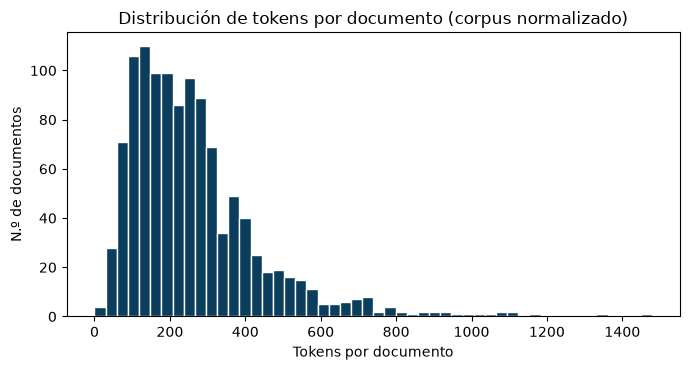

In [14]:
# 5.4 Histograma: distribución de la cantidad de tokens por documento (corpus normalizado)
longitudes = df_prep["tokens_norm"].apply(len)
print(longitudes.describe())

plt.figure(figsize=(7, 3.8))
plt.hist(longitudes, bins=50, color="#0b3d5c", edgecolor="white")
plt.xlabel("Tokens por documento")
plt.ylabel("N.º de documentos")
plt.title("Distribución de tokens por documento (corpus normalizado)")
plt.tight_layout()
plt.savefig("reporte/img/histograma.png", dpi=120)
plt.show()

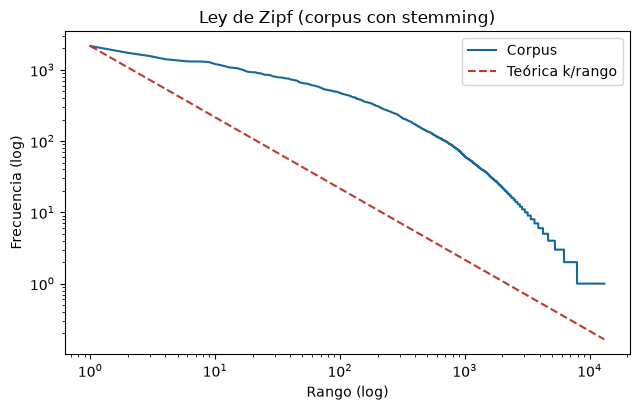

In [15]:
# 5.5 Ley de Zipf: frecuencia vs. rango en escala log-log (corpus con stemming)
frec_stem = Counter(flatten(df_prep["tokens_stem"]))
frecs = sorted(frec_stem.values(), reverse=True)
rangos = range(1, len(frecs) + 1)

k = frecs[0]                       # constante ≈ frecuencia de la palabra de rango 1
teorica = [k / r for r in rangos]  # curva teórica f(rango) ≈ k / rango

plt.figure(figsize=(6.5, 4.2))
plt.loglog(list(rangos), frecs, color="#16679a", label="Corpus")
plt.loglog(list(rangos), teorica, "--", color="#c0392b", label="Teórica k/rango")
plt.xlabel("Rango (log)")
plt.ylabel("Frecuencia (log)")
plt.title("Ley de Zipf (corpus con stemming)")
plt.legend()
plt.tight_layout()
plt.savefig("reporte/img/zipf.png", dpi=120)
plt.show()

In [16]:
# 5.6 Comparación por categoría: top-10 de palabras (corpus normalizado legible)
categorias_comparar = ["Macroeconomia", "Sostenibilidad", "Innovacion"]
for c in categorias_comparar:
    sub = flatten(df_prep.loc[df_prep["Type"] == c, "tokens_norm"])
    top10 = [w for w, _ in Counter(sub).most_common(10)]
    print(f"{c:15s}: {top10}")

Macroeconomia  : ['inflación', 'precios', 'año', 'bbva', 'crecimiento', 'mayor', 'alimentos', 'aumento', 'tasa', 'economía']
Sostenibilidad : ['bbva', 'energía', 'sostenible', 'agua', 'sostenibilidad', 'además', 'millones', 'puede', 'cambio', 'cada']
Innovacion     : ['bbva', 'clientes', 'datos', 'banco', 'empresas', 'digital', 'través', 'innovación', 'tecnología', 'españa']


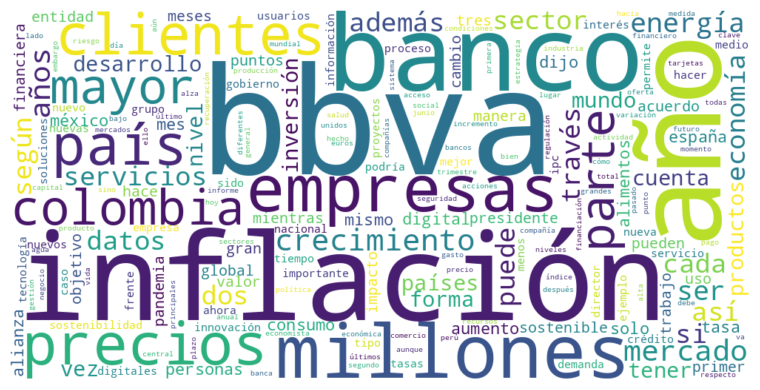

In [17]:
# 5.7 Nube de palabras del vocabulario normalizado (legible)
nube = WordCloud(
    width=1000, height=500, background_color="white", colormap="viridis"
).generate_from_frequencies(frec)  # 'frec' viene de la celda 5.3

plt.figure(figsize=(8, 4))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.savefig("reporte/img/nube.png", dpi=120)
plt.show()

## 6. Análisis

**1. ¿La curva de Zipf del corpus se parece a la curva teórica vista en clase? ¿Qué diferencias observa y por qué?**

Sí, la curva del corpus (Sección 5.5) sigue la forma decreciente característica de la Ley de Zipf y se aproxima a la recta teórica *f(rango) ≈ k/rango* en el tramo medio. Las diferencias aparecen en los **extremos**: en los rangos más altos (palabras más frecuentes) la curva real queda algo por debajo de la ideal, y en la **cola** se forma un "escalón" plano por los miles de palabras que aparecen una sola vez (*hapax legomena*). Esto ocurre porque Zipf es una regularidad empírica, no una ley exacta, y porque el corpus es finito, de dominio específico (noticias financieras) y fue sometido a stemming, lo que altera las frecuencias reales.

**2. ¿Cuánto se redujo el vocabulario en cada paso de normalización? ¿Cuál tuvo mayor impacto?**

| Paso | Tipos | Δ Tipos |
|------|------:|--------:|
| Tokenización | 38,947 | — |
| Minúsculas | 36,099 | −7.3 % |
| Quitar puntuación | 27,315 | −24.3 % |
| Quitar stopwords | 27,104 | −0.8 % |
| Stemming | 13,103 | −51.6 % |

El **stemming** tuvo el mayor impacto sobre el **vocabulario (tipos)**: lo redujo a la mitad (−51.6 %). En cambio, sobre los **tokens (ocurrencias)** el mayor impacto lo tuvo **quitar stopwords** (−48.3 %). En total el vocabulario cayó de 38,947 a 13,103 tipos (**−66.4 %**).

**3. ¿Encontró algún caso donde quitar stopwords haya afectado el significado de una noticia?**

Sí. La lista de stopwords de NLTK en español incluye la **negación `no`**. Eliminarla puede **invertir el sentido** de una frase: "el banco **no** aprobó el crédito" se convierte en "banco aprobó crédito". También se pierden preposiciones y conectores que cambian matices (p. ej., "crecimiento **sin** inflación" vs. "crecimiento **con** inflación"). Para una tabla de frecuencias o una nube esto es aceptable, pero para tareas de **análisis de sentimiento** o comprensión sería un problema serio.

**4. ¿Qué desafíos propios del español encontró realmente en el corpus?**

- **Tildes:** `isalpha()` las conserva, pero el `SnowballStemmer` **las elimina** (`aseguró`→`asegur`, `andrés`→`andres`), y en español la tilde distingue significado y tiempo (`está` vs. `esta`, `habló` vs. `hablo`).
- **Signos de apertura `¿ ¡`:** exclusivos del español; el tokenizador los separa y se eliminan como puntuación.
- **Stemming agresivo:** genera raíces que no son palabras (`banc`, `pod`, `sosten`), a diferencia de una lematización real.
- **Ausencia de lematizador nativo en NLTK para español**, que obligó a usar stemming como sustituto.

**5. Si tuviera que entrenar un modelo de lenguaje con este corpus, ¿normalizaría de la misma forma? Justifique.**

**No.** Esta normalización agresiva es adecuada para un EDA (frecuencias, Zipf, nube), pero **destruye información** que un modelo de lenguaje moderno necesita. En particular, no eliminaría stopwords (aportan sintaxis y contexto), no aplicaría stemming (prefiero conservar la palabra completa o usar **tokenización por subpalabras** tipo BPE), conservaría **mayúsculas, tildes y puntuación** (distinguen significado) y no descartaría números. Los modelos actuales (Transformers) aprenden a partir del texto lo más íntegro posible; una limpieza tan fuerte solo tiene sentido para modelos clásicos de bolsa de palabras o para análisis estadístico exploratorio como el de este laboratorio.